# Phase 2 — External Factor Collection
**Project:** BYD Stock Price Volatility Analysis
**Author:** Petru Andrei Piculescu — Polytech Nice Sophia / Xidian University
**Supervisor:** Professor Ru Zong, Xidian University

Collects external factors and merges them onto the BYD trading calendar built in Phase 1.

Not everything attempted below makes it into the final feature set. CATL, S&P 500, VIX, Tesla, CNY/USD, Brent, Copper, PBoC LPR, and Beijing temperature do. Lithium carbonate and Caixin PMI are attempted here but dropped afterwards -- no free source returned usable history for either, so they aren't carried into Phase 3.


In [1]:
# Install and import in one cell — avoids 'not defined' errors if session restarts
!pip install -q yfinance akshare pandas-datareader requests openpyxl

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io, os

import yfinance as yf
import akshare as ak
import pandas_datareader.data as web

START = '2015-01-01'
END   = '2025-01-01'
print('Ready.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 114.5 MB/s eta 0:00:00
Ready.


In [2]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# GitHub-clone friendly: if this notebook was cloned via git (e.g. by Professor Zong,
# or run locally / on Colab after `!git clone`), PROJECT defaults to the repo root ('.'),
# so data/models/figures resolve as relative folders alongside this notebook.
# Only fall back to a personal Drive path when running in Colab outside of a clone.
if IN_COLAB and not os.path.exists('data'):
    PROJECT = '/content/drive/MyDrive/BYD_Stock_Project_clean'
else:
    PROJECT = '.'

DATA    = f'{PROJECT}/data'
MODELS  = f'{PROJECT}/models'
FIGURES = f'{PROJECT}/figures'
for folder in [DATA, MODELS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

print(f'Project root: {PROJECT}')

df_base = pd.read_csv(DATA + '/byd_phase1_dataset.csv', parse_dates=['Date'], index_col='Date')
df_base.sort_index(inplace=True)
df_base = df_base.ffill()
print(f'Phase 1 dataset loaded: {df_base.shape}')


Mounted at /content/drive
Phase 1 dataset loaded: (2670, 11)


## A — Financial markets (yfinance)

In [3]:
TICKERS = ['^GSPC', '^VIX', 'TSLA', 'BZ=F', 'HG=F', '000001.SS']
NAMES   = ['SP500', 'VIX', 'Tesla', 'Brent_Oil', 'Copper', 'SSE']

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=True)

df_markets = pd.DataFrame()
for ticker, name in zip(TICKERS, NAMES):
    try:
        df_markets[name] = raw['Close'][ticker]
    except Exception as e:
        print(f'  {name}: {e}')

df_markets.index.name = 'Date'
df_markets = df_markets.ffill()
print(f'Market data: {df_markets.shape}')
print(df_markets.isnull().sum())

[*********************100%***********************]  6 of 6 completed


Market data: (2597, 6)
SP500        0
VIX          0
Tesla        0
Brent_Oil    0
Copper       0
SSE          1
dtype: int64


## B — Macroeconomic (FRED)

In [4]:
# CNY/USD from Federal Reserve database (free, no API key)
cnyusd = pd.DataFrame(columns=['CNYUSD'])
try:
    cnyusd = web.DataReader('DEXCHUS', 'fred', start=START, end=END)
    cnyusd.columns = ['CNYUSD']
    cnyusd = cnyusd.ffill()
    print(f'CNY/USD: {len(cnyusd)} obs')
except Exception as e:
    print(f'FRED failed: {e}')
    print('Manual: https://fred.stlouisfed.org/series/DEXCHUS')

CNY/USD: 2610 obs


## C — Chinese market data (akshare)

In [5]:
# CATL (300750) — BYD's main battery competitor
catl = pd.DataFrame(columns=['CATL_Close'])
try:
    raw = ak.stock_zh_a_hist(symbol='300750', period='daily',
                              start_date=START.replace('-',''), end_date=END.replace('-',''),
                              adjust='hfq')
    raw.rename(columns={'日期':'Date','收盘':'CATL_Close'}, inplace=True)
    raw['Date'] = pd.to_datetime(raw['Date'])
    raw.set_index('Date', inplace=True)
    catl = raw[['CATL_Close']]
    print(f'CATL: {len(catl)} trading days')
except Exception as e:
    print(f'CATL failed: {e}')

CATL: 1594 trading days


In [6]:
# Lithium carbonate -- key battery input cost. Different endpoint than the one tried
# in Phase 1 (futures market instead of spot), same outcome expected.
lithium = pd.DataFrame(columns=['Lithium_CNY_ton'])
try:
    raw = ak.futures_zh_spot(symbol='LC', market='GFEX')
    raw['date'] = pd.to_datetime(raw['date'])
    raw.set_index('date', inplace=True)
    raw.index.name = 'Date'
    lithium = raw[['price']].rename(columns={'price': 'Lithium_CNY_ton'})
    print(f'Lithium: {len(lithium)} obs')
except Exception as e:
    print(f'Lithium failed again ({e}), same as in Phase 1. Not pursuing a manual download for this factor: '
          'it stays excluded from the dataset, and this is noted as a limitation in the report rather than worked around.')


Lithium failed again (Length mismatch: Expected axis has 1 elements, new values have 50 elements), same as in Phase 1. Not pursuing a manual download for this factor: it stays excluded from the dataset, and this is noted as a limitation in the report rather than worked around.


In [7]:
# PBoC Loan Prime Rate — monthly benchmark lending rate
pboc = pd.DataFrame(columns=['PBoC_LPR_1y'])
try:
    raw = ak.macro_china_lpr()
    date_col = raw.columns[0]
    rate_col = [c for c in raw.columns if 'LPR1' in str(c) or '1' in str(c)][0]
    pboc = raw[[date_col, rate_col]].copy()
    pboc[date_col] = pd.to_datetime(pboc[date_col])
    pboc.set_index(date_col, inplace=True)
    pboc.index.name = 'Date'
    pboc.columns = ['PBoC_LPR_1y']
    pboc['PBoC_LPR_1y'] = pd.to_numeric(pboc['PBoC_LPR_1y'], errors='coerce')
    print(f'PBoC LPR: {len(pboc)} obs')
except Exception as e:
    print(f'PBoC failed: {e}')

PBoC LPR: 1574 obs


In [8]:
# Caixin Manufacturing PMI -- monthly industrial survey (>50 = expansion)
pmi = pd.DataFrame(columns=['Caixin_PMI'])
try:
    raw = ak.macro_china_pmi_yearly()
    caixin_col = [c for c in raw.columns if 'caixin' in str(c).lower() or '财新' in str(c)]
    if caixin_col:
        date_col = raw.columns[0]
        pmi = raw[[date_col, caixin_col[0]]].copy()
        pmi[date_col] = pd.to_datetime(pmi[date_col])
        pmi.set_index(date_col, inplace=True)
        pmi.index.name = 'Date'
        pmi.columns = ['Caixin_PMI']
        pmi['Caixin_PMI'] = pd.to_numeric(pmi['Caixin_PMI'], errors='coerce')
        print(f'Caixin PMI: {len(pmi)} obs')
    else:
        print(f'Caixin column not present in this akshare endpoint (columns: {list(raw.columns)}). '
              'Dropping PMI rather than chasing a moving target -- the endpoint appears to have changed shape.')
except Exception as e:
    print(f'PMI failed: {e}. Excluded from the dataset, same reasoning as lithium above.')


Caixin column not present in this akshare endpoint (columns: ['商品', '日期', '今值', '预测值', '前值']). Dropping PMI rather than chasing a moving target -- the endpoint appears to have changed shape.


## D — Climate (Open-Meteo)

In [9]:
# Beijing average daily temperature — proxy for EV demand seasonality
temp = pd.DataFrame(columns=['Beijing_Temp_C'])
try:
    url = ('https://archive-api.open-meteo.com/v1/archive'
           '?latitude=39.9042&longitude=116.4074'
           f'&start_date={START}&end_date=2024-12-31'
           '&daily=temperature_2m_mean&timezone=Asia%2FShanghai')
    data = requests.get(url, timeout=30).json()
    temp = pd.DataFrame({'Beijing_Temp_C': data['daily']['temperature_2m_mean']},
                         index=pd.to_datetime(data['daily']['time']))
    temp.index.name = 'Date'
    print(f'Beijing temperature: {len(temp)} daily obs')
except Exception as e:
    print(f'Open-Meteo failed: {e}')

Beijing temperature: 3653 daily obs


## E — Merge onto BYD trading calendar

BYD trading days are the reference index.  
`ffill()` only — never `interpolate()` — to prevent look-ahead bias.

In [10]:
def safe_join(df_main, df_factor, label):
    if df_factor.empty:
        print(f'  skipping {label} (empty)')
        return df_main
    cols = [c for c in df_factor.columns if c not in df_main.columns]
    if not cols:
        print(f'  skipping {label} (already present)')
        return df_main
    merged = df_main.join(df_factor[cols], how='left')
    merged[cols] = merged[cols].ffill()
    print(f'  {label}: {merged[cols].isnull().sum().sum()} missing after ffill')
    return merged

df_all = df_base.copy()
df_all = safe_join(df_all, df_markets, 'SP500, VIX, Tesla, Brent, Copper, SSE')
df_all = safe_join(df_all, cnyusd,     'CNY/USD')
df_all = safe_join(df_all, catl,       'CATL')
df_all = safe_join(df_all, lithium,    'Lithium')
df_all = safe_join(df_all, pboc,       'PBoC LPR')
df_all = safe_join(df_all, pmi,        'Caixin PMI')
df_all = safe_join(df_all, temp,       'Beijing temperature')

print(f'\nFinal dataset: {df_all.shape}')
print(f'Columns: {list(df_all.columns)}')

for col, pct in (df_all.isnull().sum() / len(df_all) * 100).round(1).items():
    flag = 'WARN' if pct > 5 else 'ok'
    print(f'  [{flag}] {col:<25} {pct}%')


  SP500, VIX, Tesla, Brent, Copper, SSE: 0 missing after ffill
  skipping CNY/USD (already present)
  CATL: 836 missing after ffill
  skipping Lithium (empty)
  PBoC LPR: 0 missing after ffill
  skipping Caixin PMI (empty)
  Beijing temperature: 0 missing after ffill

Final dataset: (2670, 20)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'DailyReturn', 'CNYUSD', 'SSE_Close', 'SSE_Return', 'Vol_20d', 'Vol_60d', 'SP500', 'VIX', 'Tesla', 'Brent_Oil', 'Copper', 'SSE', 'CATL_Close', 'PBoC_LPR_1y', 'Beijing_Temp_C']
  [ok] Open                      0.0%
  [ok] High                      0.0%
  [ok] Low                       0.0%
  [ok] Close                     0.0%
  [ok] Volume                    0.0%
  [ok] DailyReturn               0.0%
  [ok] CNYUSD                    0.0%
  [ok] SSE_Close                 0.0%
  [ok] SSE_Return                0.0%
  [ok] Vol_20d                   0.7%
  [ok] Vol_60d                   2.2%
  [ok] SP500                     0.0%
  [ok] VIX           

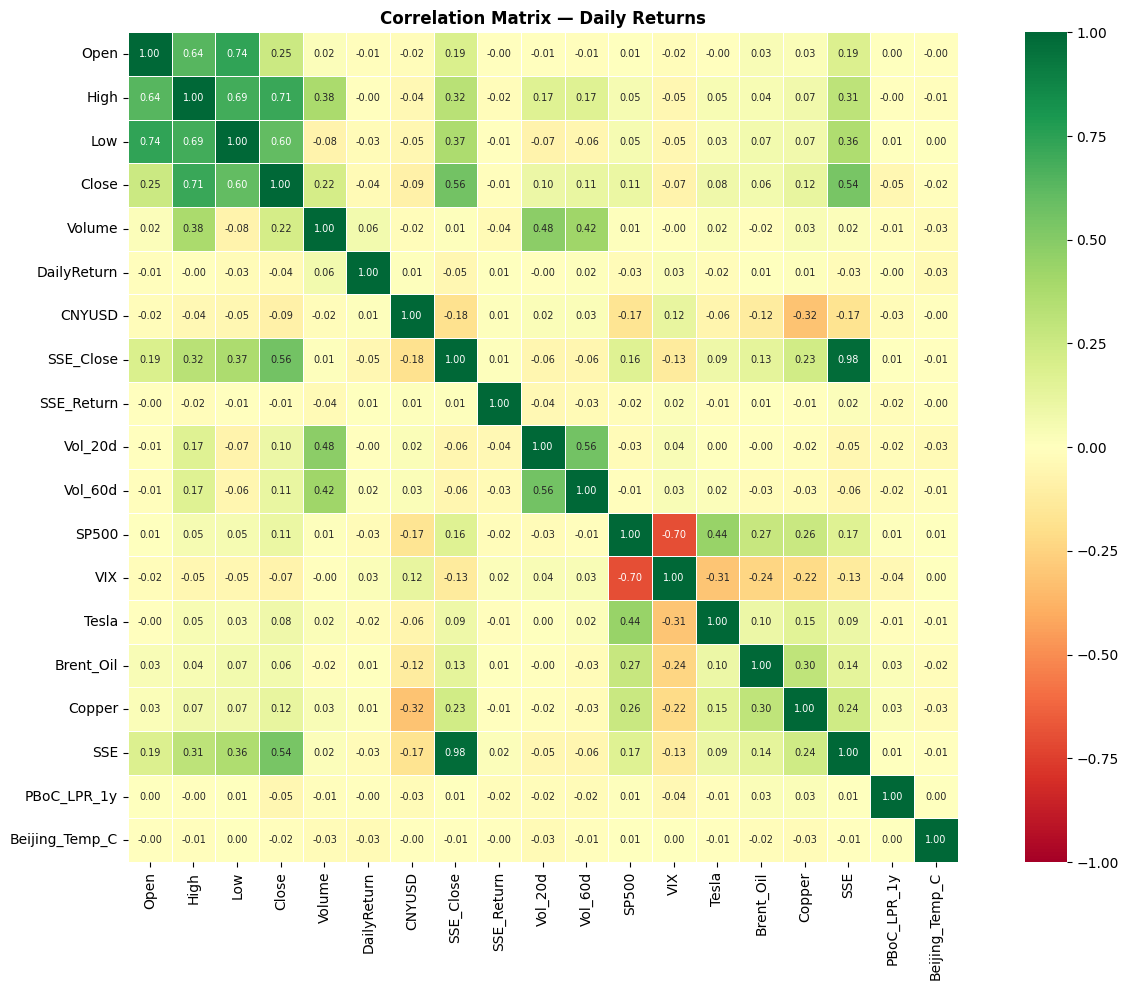


Top factors correlated with BYD Close return:
High         0.711952
Low          0.602430
SSE_Close    0.557574
SSE          0.542973
Open         0.250425
Volume       0.216269
Copper       0.123872
Vol_60d      0.113057
SP500        0.108648
Vol_20d      0.097800


In [11]:
# Correlation heatmap on daily returns (not price levels — avoids spurious correlations)
valid_cols = [c for c in df_all.columns
              if df_all[c].isnull().mean() < 0.2 and df_all[c].dtype in ['float64','int64']]

corr = df_all[valid_cols].pct_change().dropna().corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=0.4, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Daily Returns', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + '/fig_correlation_all_factors.png', dpi=150, bbox_inches='tight')
plt.show()

if 'Close' in corr.columns:
    print('\nTop factors correlated with BYD Close return:')
    print(corr['Close'].drop('Close').abs().sort_values(ascending=False).head(10).to_string())

In [12]:
df_all.to_csv(DATA + '/byd_all_factors_dataset.csv')
print(f'Saved: {DATA}byd_all_factors_dataset.csv  shape={df_all.shape}')


Saved: /content/drive/MyDrive/BYD_Stock_Project_clean/data/byd_all_factors_dataset.csv  shape=(2670, 20)
